# Tutorial 01 - Data Loading, Exploration & Basic Spatial Estimation

**Package:** stamps_v3  
**MATLAB equivalent:** `IOLIBtutorial.m` + `GENLIBtutorial.m` + `STATLIBtutorial.m` §1-3  
**Dataset:** Falmagne soil dataset - 118 georeferenced soil samples from the Dinant area, Belgium

---

## Learning objectives

By the end of this notebook you will be able to:

1. Load a **GeoEAS-format** text file using `numpy` / `pandas`.
2. Explore and visualise a spatial dataset (locations, histograms, scatter plots).
3. Build a **regular estimation grid** with `numpy.meshgrid`.
4. Apply two simple **non-parametric spatial estimators**:
   - Inverse-distance weighting (IDW)
   - Gaussian kernel smoothing
5. Display **spatial estimation maps** with `matplotlib`.

These foundational skills are the building blocks for all subsequent tutorials.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# make the stamps package importable

from stamps.general import read_geoeas
from stamps.estimation.idw import idw_kdtree
from stamps.estimation.kernelsmoothing import kernelsmoothing_kdtree
from stamps.graph.dataplot import (
    histplot, colorplot, plot_ecdf, plot_grid_map
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')
print('Data directory:', DATA_DIR)

Data directory: /Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/tutorials/data


## 1. Load the Falmagne dataset

`Falmagne.txt` follows the **GeoEAS** format:

```
Line 1      : file title
Line 2      : number of columns p
Lines 3...2+p : column names
Remaining   : data (whitespace-delimited)
```

We parse it with a compact helper that replicates MATLAB's `readGeoEAS`.


In [2]:
title, col_names, data = read_geoeas(os.path.join(DATA_DIR, 'Falmagne.txt'))
df = pd.DataFrame(data, columns=col_names)

print('Title :', title)
print(f'Shape : {df.shape[0]} samples x {df.shape[1]} variables\n')
print(df.head())

Title : Falmagne hard data set - Granulometric composition of 118 locations in Dinant area, Belgium.
Shape : 118 samples x 6 variables

   Easting (meters)  Northing (meters)  Sand content (%)  Silt content (%)  \
0          179495.0           100600.0              23.9              62.2   
1          190735.0            98755.0              23.1              56.4   
2          181720.0            94860.0               9.0              77.5   
3          193340.0            90005.0              17.8              49.8   
4          179535.0           100720.0              19.6              69.3   

   Clay content (%)  soil type (code 1 to 4)  
0              13.9                      3.0  
1              20.5                      2.0  
2              13.5                      4.0  
3              32.4                      2.0  
4              11.1                      3.0  


In [3]:
# Extract columns
ch   = df.iloc[:, 0:2].values
sand = df.iloc[:, 2].values
silt = df.iloc[:, 3].values
clay = df.iloc[:, 4].values
code = df.iloc[:, 5].values.astype(int)

print(f'Samples : {len(sand)}')
print(f'Sand    : mean={sand.mean():.1f}%  range=[{sand.min():.1f}, {sand.max():.1f}]')
print(f'Silt    : mean={silt.mean():.1f}%  range=[{silt.min():.1f}, {silt.max():.1f}]')
print(f'Clay    : mean={clay.mean():.1f}%  range=[{clay.min():.1f}, {clay.max():.1f}]')
print(f'Codes   : {np.unique(code)}')


Samples : 118
Sand    : mean=15.2%  range=[2.4, 43.4]
Silt    : mean=66.1%  range=[39.6, 88.0]
Clay    : mean=18.7%  range=[6.8, 42.3]
Codes   : [1 2 3 4]


## 2. Visualise sampling locations

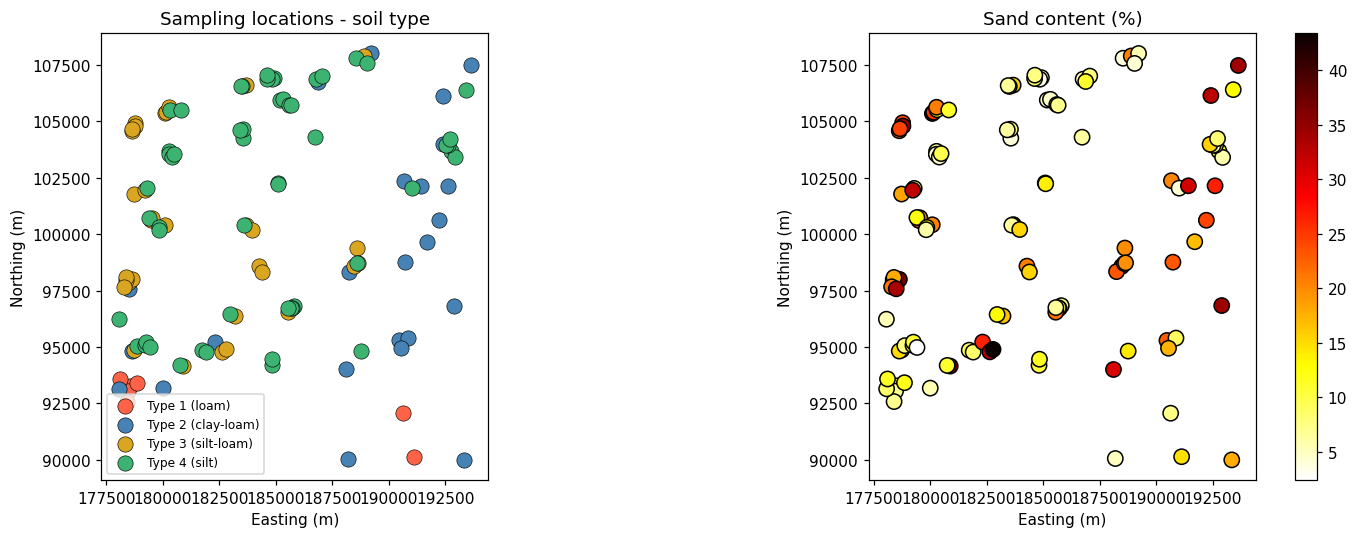

In [4]:
SOIL_COLORS = {1: 'tomato', 2: 'steelblue', 3: 'goldenrod', 4: 'mediumseagreen'}
SOIL_LABELS = {1: 'Type 1 (loam)', 2: 'Type 2 (clay-loam)',
               3: 'Type 3 (silt-loam)', 4: 'Type 4 (silt)'}
categories = list(SOIL_COLORS.keys())
cat_labels = [SOIL_LABELS[k] for k in categories]
cat_colors = [SOIL_COLORS[k] for k in categories]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colorplot(ch, codes=code, ax=axes[0],
          categories=categories, labels=cat_labels, colors=cat_colors,
          xlabel='Easting (m)', ylabel='Northing (m)',
          title='Sampling locations - soil type', show=False)

colorplot(ch, z=sand, ax=axes[1], cmap='hot_r',
          xlabel='Easting (m)', ylabel='Northing (m)',
          title='Sand content (%)', show=False)

plt.tight_layout(); plt.show()


## 3. Descriptive statistics

In [5]:
variables = {'Sand': sand, 'Silt': silt, 'Clay': clay}

rows = []
for name, v in variables.items():
    rows.append({
        'Variable': name,
        'Mean':     np.mean(v),
        'Variance': np.var(v, ddof=1),
        'Std dev':  np.std(v, ddof=1),
        'Skewness': stats.skew(v),
        'Kurtosis': stats.kurtosis(v),
        'Min':      np.min(v),
        'Max':      np.max(v),
    })

print(pd.DataFrame(rows).set_index('Variable').round(2).to_string())


           Mean  Variance  Std dev  Skewness  Kurtosis   Min   Max
Variable                                                          
Sand      15.18     91.26     9.55      0.83     -0.18   2.4  43.4
Silt      66.07    127.70    11.30     -0.34     -0.80  39.6  88.0
Clay      18.74     55.60     7.46      1.24      1.27   6.8  42.3


## 4. Histograms and kernel density estimates

A **scaled histogram** (density, not counts) allows visual comparison across variables.  The Gaussian KDE provides a smooth estimate of the underlying probability density.


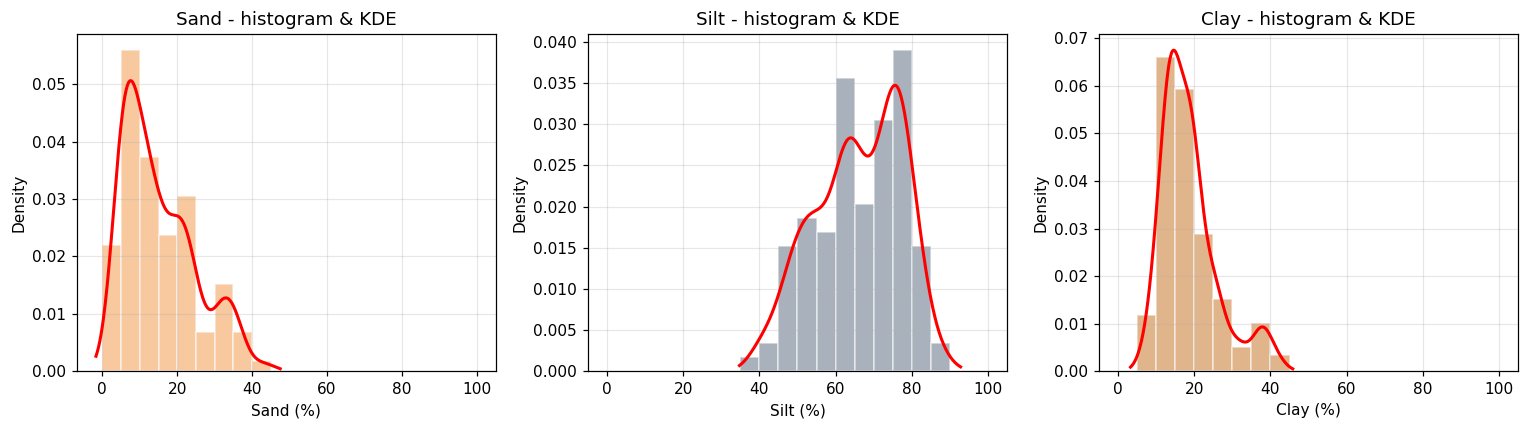

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bins   = np.linspace(0, 100, 21)
colors = ['sandybrown', 'slategray', 'peru']

for ax, (name, v), col in zip(axes, variables.items(), colors):
    histplot(v, bins=bins, ax=ax, density=True, kde=True,
             bw_method=0.3, color=col, alpha=0.6, label='Histogram',
             xlabel=f'{name} (%)', show=False)
    ax.set_title(f'{name} - histogram & KDE')

plt.tight_layout(); plt.show()


## 5. Empirical CDF

The empirical CDF $\hat{F}(z) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}[z_i \le z]$ is a non-parametric estimate of the true CDF.  We overlay the CDF obtained by numerically integrating the KDE.


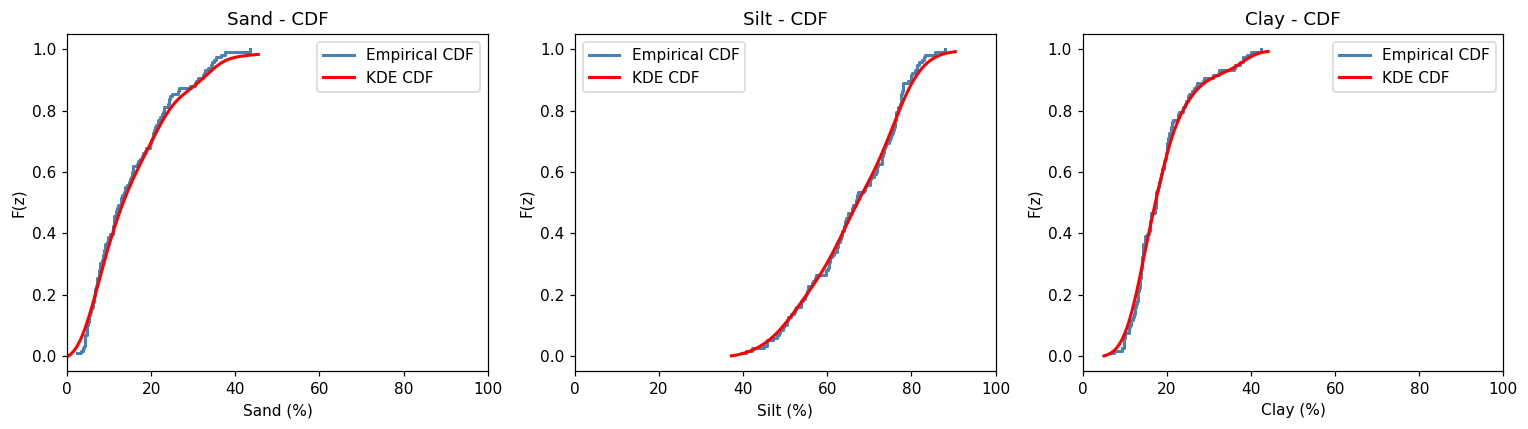

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, v), col in zip(axes, variables.items(), colors):
    plot_ecdf(ax, v, kde=True, bw_method=0.3,
              xlabel=f'{name} (%)', title=f'{name} - CDF', xlim=[0, 100])

plt.tight_layout(); plt.show()


## 6. Build a regular estimation grid

We create a **17 x 19 = 323-node** regular grid with 1 000 m spacing -
matching the MATLAB tutorial.

```matlab
% MATLAB equivalent:
minc=[178000 90000]; dc=[1000 1000]; nc=[17 19];
[ck]=creategrid(minc, dc, nc);
```

```python
# Python equivalent:
EE, NN = np.meshgrid(east_vals, north_vals)
ck = np.column_stack([EE.ravel(), NN.ravel()])
```


Grid : 17 x 19 = 323 nodes
Easting  : 178000 to 194000 m
Northing : 90000 to 108000 m


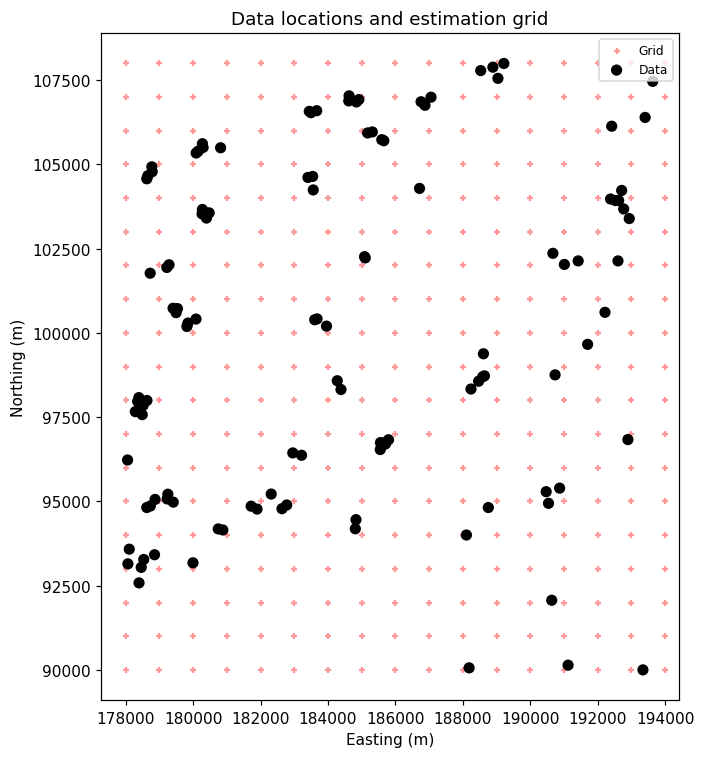

In [8]:
min_e, min_n = 178_000, 90_000
d_e,   d_n   = 1_000,   1_000
n_e,   n_n   = 17,      19

east_vals  = min_e + np.arange(n_e) * d_e
north_vals = min_n + np.arange(n_n) * d_n
EE, NN     = np.meshgrid(east_vals, north_vals)
ck         = np.column_stack([EE.ravel(), NN.ravel()])

print(f'Grid : {n_e} x {n_n} = {len(ck)} nodes')
print(f'Easting  : {east_vals[0]:.0f} to {east_vals[-1]:.0f} m')
print(f'Northing : {north_vals[0]:.0f} to {north_vals[-1]:.0f} m')

fig, ax = plt.subplots(figsize=(7, 7))
colorplot(ch, z=np.zeros(len(ch)), ax=ax, s=40, cmap='gray', colorbar=False,
          ch_grid=ck, xlabel='Easting (m)', ylabel='Northing (m)',
          title='Data locations and estimation grid', show=False)
ax.legend(['Grid', 'Data'], fontsize=8)
plt.tight_layout(); plt.show()


## 7. Inverse-distance weighting (IDW)

$$\hat{z}(\mathbf{s}_0) = \frac{\displaystyle\sum_{i=1}^n w_i\,z_i}{\displaystyle\sum_{i=1}^n w_i}, \qquad w_i = \frac{1}{d_i^p}$$

- $p = \infty$ -> **nearest-neighbour** (step-function map)  
- $p = 2$ -> classic **IDW** (smooth transitions)

Corresponds to MATLAB's `invdist(ck, ch, z, p, nhmax, dmax)`.


In [9]:
# Nearest-neighbour: nnear=1 returns the single closest data value
zk_nn  = idw_kdtree(ch, sand, ck, nnear=1)

# IDW p=2: weighted average of the 20 nearest neighbours
zk_idw = idw_kdtree(ch, sand, ck, nnear=20, power=2)

print(f'Nearest-neighbour: {np.sum(~np.isnan(zk_nn))} / {len(ck)} nodes')
print(f'IDW (p=2)        : {np.sum(~np.isnan(zk_idw))} / {len(ck)} nodes')

Nearest-neighbour: 323 / 323 nodes
IDW (p=2)        : 323 / 323 nodes


## 8. Gaussian kernel smoothing

$$\hat{z}(\mathbf{s}_0) = \frac{\displaystyle\sum_i K_h(\|\mathbf{s}_0-\mathbf{s}_i\|)\,z_i}{\displaystyle\sum_i K_h(\|\mathbf{s}_0-\mathbf{s}_i\|)}, \qquad K_h(d) = e^{-d^2/(2h^2)}$$

Corresponds to MATLAB's `kernelsmoothing(ck, ch, z, h^2, nhmax, dmax)`.


In [10]:
# bandwidth = sqrt(bandwidth²) = sqrt(1e6) = 1000 m
# kernelsmoothing_kdtree uses exp(-d² / (2·bandwidth²)) Gaussian weights
zk_ks = kernelsmoothing_kdtree(ch, sand, ck, bandwidth=1_000, nhmax=20)

print(f'Kernel smoothing: {np.sum(~np.isnan(zk_ks))} / {len(ck)} nodes')

Kernel smoothing: 323 / 323 nodes


## 9. Visualise the estimation maps

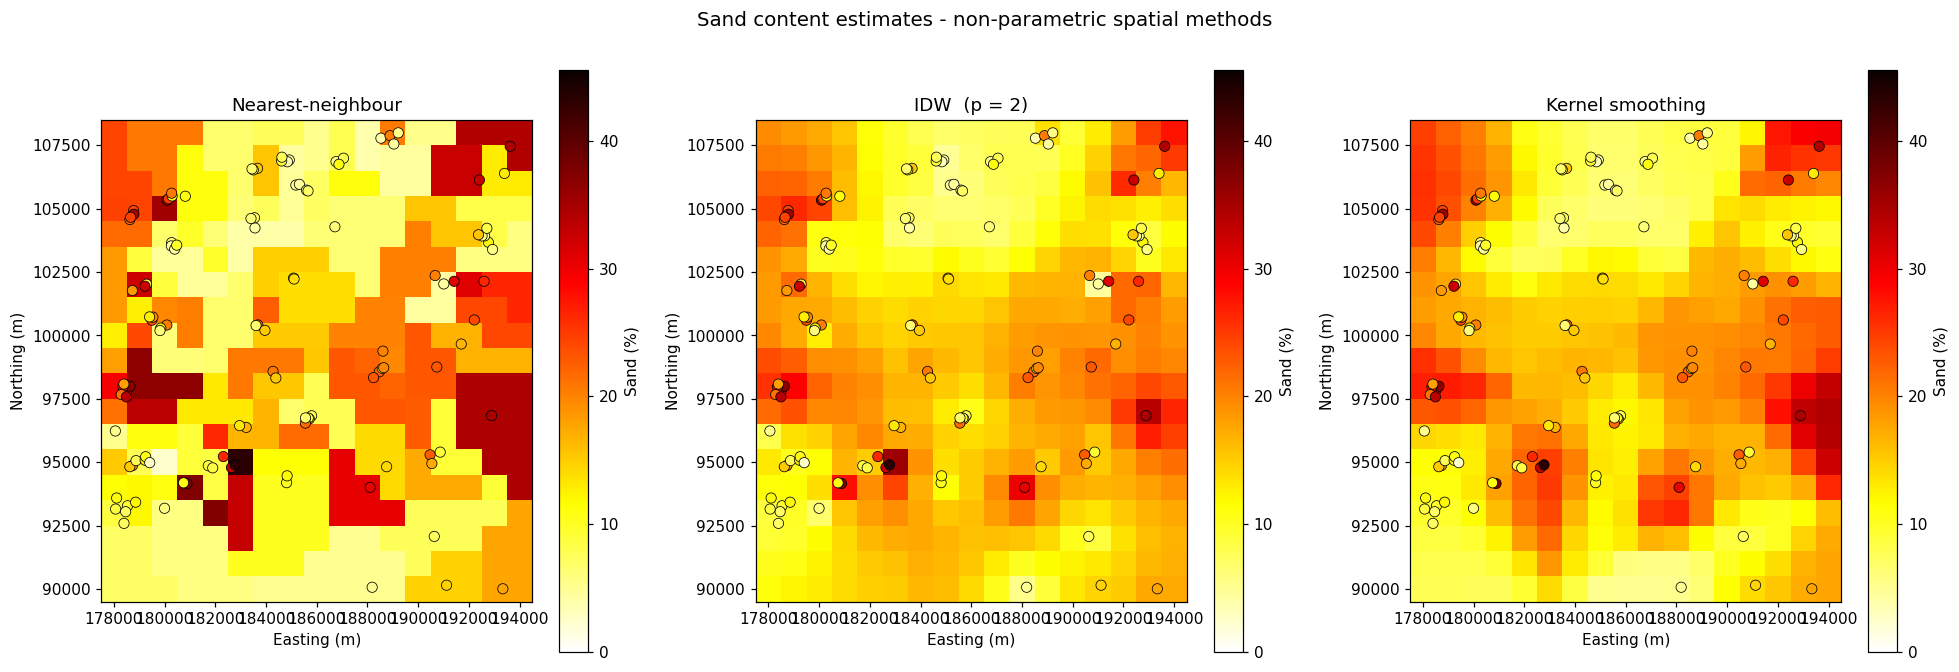

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vlo, vhi = 0, sand.max() * 1.05
plot_grid_map(axes[0], ck, zk_nn,  'Nearest-neighbour', ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')
plot_grid_map(axes[1], ck, zk_idw, 'IDW  (p = 2)',      ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')
plot_grid_map(axes[2], ck, zk_ks,  'Kernel smoothing',  ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')
plt.suptitle('Sand content estimates - non-parametric spatial methods', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 10. Summary & next steps

| Method | Requires covariance model? | Provides error variance? |
|---|:---:|:---:|
| Nearest-neighbour | No | No |
| IDW | No | No |
| Kernel smoothing | No | No |
| **Kriging** (Tutorial 04) | **Yes** | **Yes** |
| **BME** (Tutorials 05-07) | **Yes** | **Yes (full posterior PDF)** |

**Key limitation of non-parametric methods:** they ignore spatial autocorrelation and cannot quantify estimation uncertainty. The subsequent tutorials address this by first characterising the covariance structure (Tutorials 02-03) and then using it for inference (Tutorials 04-07).


In [12]:
import pickle

tutorial_data = {
    'ch': ch, 'sand': sand, 'silt': silt, 'clay': clay, 'code': code,
    'ck': ck, 'EE': EE, 'NN': NN,
    'east_vals': east_vals, 'north_vals': north_vals,
    'n_e': n_e, 'n_n': n_n,
}

save_path = os.path.join(DATA_DIR, 'tutorial01_data.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(tutorial_data, f)

print('Saved:', save_path)
print('Keys :', list(tutorial_data.keys()))


Saved: /Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/tutorials/data/tutorial01_data.pkl
Keys : ['ch', 'sand', 'silt', 'clay', 'code', 'ck', 'EE', 'NN', 'east_vals', 'north_vals', 'n_e', 'n_n']
